# Preprocessing Pipeline
Run top to bottom.

In [1]:
import sys, os
from pathlib import Path

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
import pandas as pd

from src.config import MAESTRO_DIR, PROCESSED_DIR, FS, SEQ_LEN, N_PITCHES

os.makedirs('../outputs/plots', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print(f'MAESTRO : {MAESTRO_DIR}')
print(f'FS={FS}  SEQ_LEN={SEQ_LEN}  N_PITCHES={N_PITCHES}')

MAESTRO : d:\Study\425\Project\Dataset\maestro-v3.0.0-midi\maestro-v3.0.0
FS=16  SEQ_LEN=128  N_PITCHES=88


## EDA

In [2]:
from src.preprocessing.midi_parser import load_maestro, get_split

sample = load_maestro(max_files=5)
print(f'Total files : 1276  (preview: {len(sample)})')
print()
for k, v in sample[0].items():
    print(f'  {k}: {v}')

Total files : 1276  (preview: 5)

  path: d:\Study\425\Project\Dataset\maestro-v3.0.0-midi\maestro-v3.0.0\2018\MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi
  split: train
  composer: Alban Berg
  title: Sonata Op. 1
  duration: 698.661160312
  year: 2018


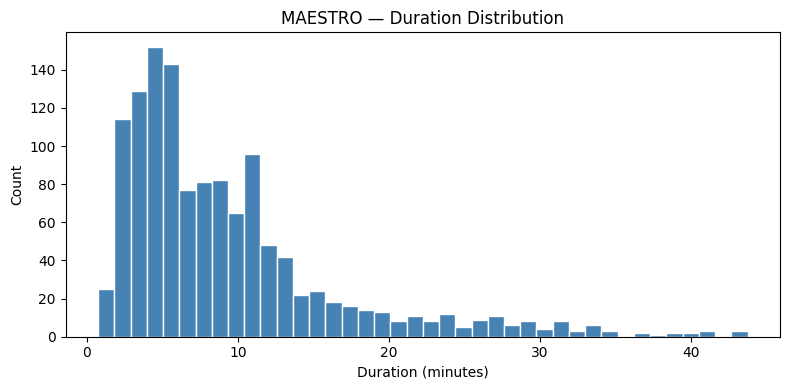

count=1276  mean=9.3  median=7.2  max=43.7 min


In [3]:
# duration histogram
df = pd.read_csv(MAESTRO_DIR / 'maestro-v3.0.0.csv')
d  = df['duration'] / 60.0

plt.figure(figsize=(8, 4))
plt.hist(d, bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.title('MAESTRO — Duration Distribution')
plt.tight_layout()
plt.savefig('../outputs/plots/eda_duration.png', dpi=300)
plt.savefig('../outputs/plots/eda_duration.pdf')
plt.show()

print(f'count={len(d)}  mean={d.mean():.1f}  median={d.median():.1f}  max={d.max():.1f} min')

In [4]:
note_counts    = []
pitch_counts   = np.zeros(88)
all_velocities = []

paths  = [str(MAESTRO_DIR / row['midi_filename']) for _, row in df.iterrows()]
failed = 0

print(f'Scanning {len(paths)} files...')
for i, path in enumerate(paths):
    try:
        pm    = pretty_midi.PrettyMIDI(path)
        notes = [n for inst in pm.instruments for n in inst.notes]
        note_counts.append(len(notes))
        for n in notes:
            if 21 <= n.pitch <= 108:
                pitch_counts[n.pitch - 21] += 1
            all_velocities.append(n.velocity)
    except Exception:
        failed += 1
    if (i + 1) % 200 == 0:
        print(f'  {i+1}/{len(paths)}')

print(f'Done — {len(paths)-failed}/{len(paths)} loaded')

Scanning 1276 files...
  200/1276
  400/1276
  600/1276
  800/1276
  1000/1276
  1200/1276
Done — 1276/1276 loaded


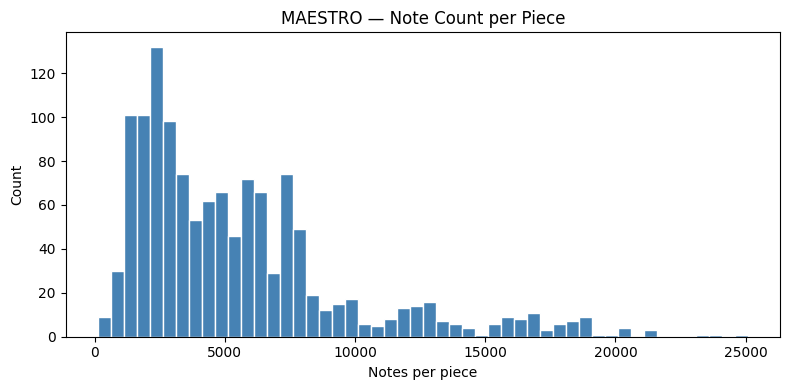

mean=5517  min=129  max=25076


In [5]:
# note count
plt.figure(figsize=(8, 4))
plt.hist(note_counts, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Notes per piece')
plt.ylabel('Count')
plt.title('MAESTRO — Note Count per Piece')
plt.tight_layout()
plt.savefig('../outputs/plots/eda_note_count.png', dpi=300)
plt.savefig('../outputs/plots/eda_note_count.pdf')
plt.show()

print(f'mean={sum(note_counts)/len(note_counts):.0f}  min={min(note_counts)}  max={max(note_counts)}')

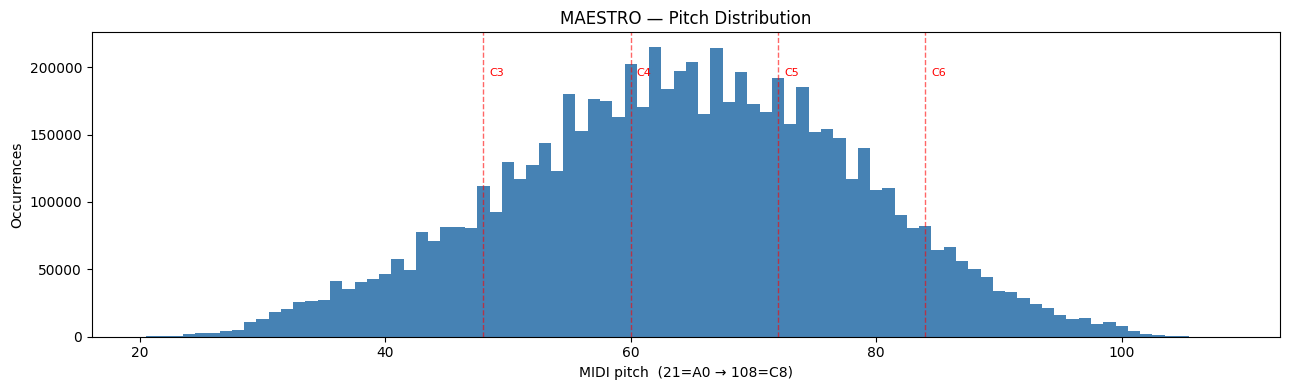

most common: 62  (D4)


In [6]:
# pitch distribution
pitch_nums = list(range(21, 109))
plt.figure(figsize=(13, 4))
plt.bar(pitch_nums, pitch_counts, color='steelblue', width=1.0)
for c, lbl in [(48, 'C3'), (60, 'C4'), (72, 'C5'), (84, 'C6')]:
    plt.axvline(c, color='red', alpha=0.6, linestyle='--', linewidth=1)
    plt.text(c + 0.5, pitch_counts.max() * 0.9, lbl, color='red', fontsize=8)
plt.xlabel('MIDI pitch  (21=A0 → 108=C8)')
plt.ylabel('Occurrences')
plt.title('MAESTRO — Pitch Distribution')
plt.tight_layout()
plt.savefig('../outputs/plots/eda_pitch.png', dpi=300)
plt.savefig('../outputs/plots/eda_pitch.pdf')
plt.show()

top = int(pitch_counts.argmax()) + 21
print(f'most common: {top}  ({pretty_midi.note_number_to_name(top)})')

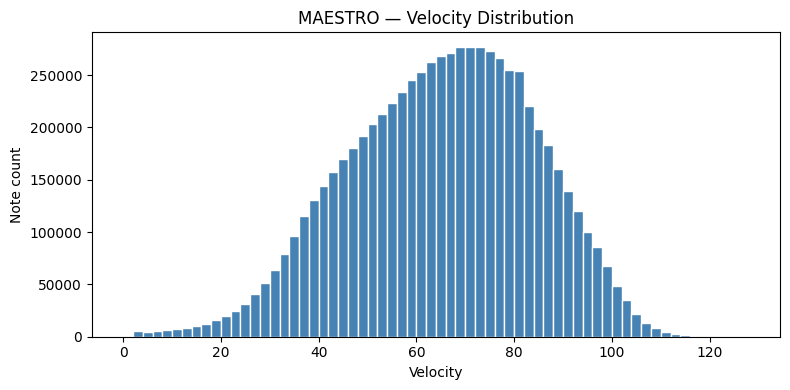

mean=64.7  min=1  max=126


In [7]:
# velocity
plt.figure(figsize=(8, 4))
plt.hist(all_velocities, bins=64, range=(0, 128), color='steelblue', edgecolor='white')
plt.xlabel('Velocity')
plt.ylabel('Note count')
plt.title('MAESTRO — Velocity Distribution')
plt.tight_layout()
plt.savefig('../outputs/plots/eda_velocity.png', dpi=300)
plt.savefig('../outputs/plots/eda_velocity.pdf')
plt.show()

print(f'mean={sum(all_velocities)/len(all_velocities):.1f}  min={min(all_velocities)}  max={max(all_velocities)}')

In [8]:
# sparsity
from src.preprocessing.piano_roll import midi_to_roll

for rec in sample[:3]:
    roll = midi_to_roll(rec['path'])
    pct  = roll.mean() * 100
    print(f'  {pct:.1f}% active  ({100-pct:.1f}% zeros)  — {Path(rec["path"]).name}')

  7.2% active  (92.8% zeros)  — MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi
  7.2% active  (92.8% zeros)  — MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MID--AUDIO_03_R2_2008_wav--2.midi
  5.7% active  (94.3% zeros)  — MIDI-Unprocessed_066_PIANO066_MID--AUDIO-split_07-07-17_Piano-e_3-02_wav--3.midi


## Preprocessing

In [9]:
from src.preprocessing.piano_roll import midi_to_roll, segment_roll

midi_path = sample[0]['path']
roll = midi_to_roll(midi_path)

print(f'file     : {Path(midi_path).name}')
print(f'shape    : {roll.shape}  (T x 88)')
print(f'duration : {roll.shape[0] / FS:.1f} s')
print(f'active   : {roll.mean()*100:.2f}%')

file     : MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi
shape    : (11263, 88)  (T x 88)
duration : 703.9 s
active   : 7.22%


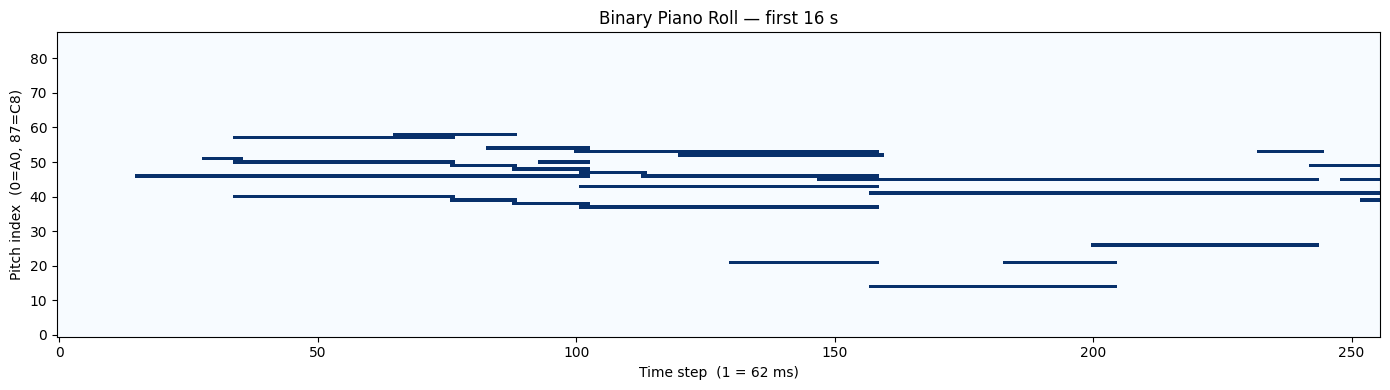

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(roll[:256].T, aspect='auto', origin='lower', cmap='Blues', interpolation='nearest')
ax.set_xlabel(f'Time step  (1 = {1000/FS:.0f} ms)')
ax.set_ylabel('Pitch index  (0=A0, 87=C8)')
ax.set_title('Binary Piano Roll — first 16 s')
plt.tight_layout()
plt.show()

window : 128 steps = 8.0 s
kept   : 87  shape each: (128, 88)


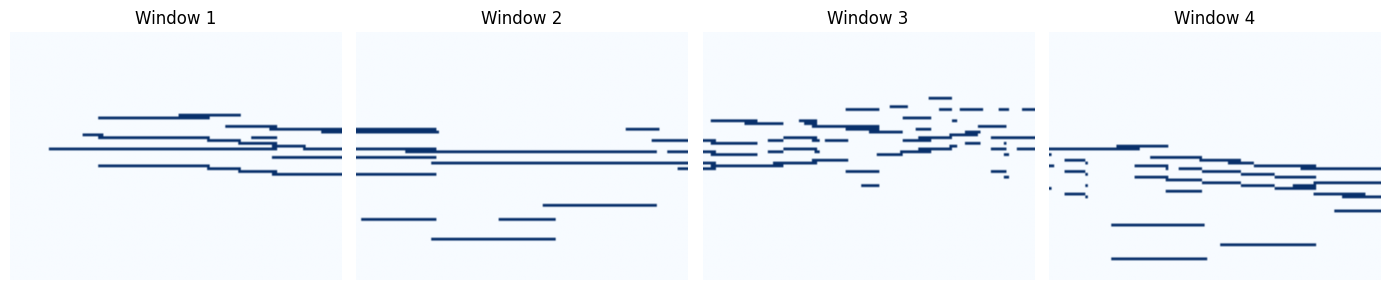

In [11]:
# segmentation
windows = segment_roll(roll)

print(f'window : {SEQ_LEN} steps = {SEQ_LEN/FS:.1f} s')
print(f'kept   : {len(windows)}  shape each: {windows[0].shape}')

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(windows[i].T, aspect='auto', origin='lower', cmap='Blues')
    ax.set_title(f'Window {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# tokenization
from src.preprocessing.tokenizer import build_tokenizer, tokenize_file
import torch

tok  = build_tokenizer()
seqs = tokenize_file(midi_path, tok)

print(f'vocab size : {len(tok.vocab)}')
if seqs:
    ids = seqs[0]
    print(f'chunks={len(seqs)}  len={len(ids)}')
    inp = torch.tensor(ids[:-1], dtype=torch.long)
    tgt = torch.tensor(ids[1:],  dtype=torch.long)
    print(f'input  : {inp.shape}')
    print(f'target : {tgt.shape}')

vocab size : 284
chunks=31  len=512
input  : torch.Size([511])
target : torch.Size([511])


## Build Arrays

Saves `train/val/test_piano_rolls.npy` to `data/processed/`.  
Shape per file: `(N, 128, 88)`. Takes 10–20 min for full dataset.

In [13]:
from src.preprocessing.midi_parser import get_split
from src.preprocessing.piano_roll  import build_npy

for name, maestro_split in [('train', 'train'), ('val', 'validation'), ('test', 'test')]:
    records  = get_split(maestro_split)
    out_path = f'../data/processed/{name}_piano_rolls.npy'
    print(f'\n{name} ({len(records)} files)')
    build_npy(records, out_path)


train (962 files)
  200/962  windows: 12600
  400/962  windows: 28469
  600/962  windows: 37925
  800/962  windows: 49516
  saved (62767, 128, 88) → ../data/processed/train_piano_rolls.npy

val (137 files)
  saved (7889, 128, 88) → ../data/processed/val_piano_rolls.npy

test (177 files)
  saved (7796, 128, 88) → ../data/processed/test_piano_rolls.npy


## DataLoader

In [14]:
import torch
from torch.utils.data import DataLoader
from src.preprocessing.piano_roll import PianoRollDataset

train_ds = PianoRollDataset('../data/processed/train_piano_rolls.npy')
val_ds   = PianoRollDataset('../data/processed/val_piano_rolls.npy')

print(f'train={len(train_ds)}  val={len(val_ds)}')

x = train_ds[0]
print(f'sample : {x.shape}  dtype={x.dtype}')
assert tuple(x.shape) == (SEQ_LEN, N_PITCHES)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print(f'batch  : {batch.shape}')

train=62767  val=7889
sample : torch.Size([128, 88])  dtype=torch.float32
batch  : torch.Size([64, 128, 88])


In [ ]:
# token dataloader
from src.preprocessing.tokenizer import build_tokenizer, TokenDataset, collate_fn

tok      = build_tokenizer()
records  = get_split('train')[:20]
token_ds = TokenDataset(records, tok)

print(f'token samples : {len(token_ds)}')

inp, tgt = token_ds[0]
print(f'input={inp.shape}  target={tgt.shape}')

token_loader = DataLoader(token_ds, batch_size=8, shuffle=True, collate_fn=collate_fn)
inp_b, tgt_b, mask_b = next(iter(token_loader))
print(f'batch input  : {inp_b.shape}')
print(f'batch target : {tgt_b.shape}')
print(f'attn mask    : {mask_b.shape}  dtype={mask_b.dtype}')

token samples : 862
input=torch.Size([511])  target=torch.Size([511])
batch input  : torch.Size([8, 511])
batch target : torch.Size([8, 511])
attn mask    : torch.Size([8, 511])  dtype=torch.bool


: 